# 2.4. Calculus

Calculus is the cornerstone of machine learning. A key step in training any machine learning model is stochaistic gradient descent \(SGD\), otherwise known as autograd.

SGD involves computing the gradients of the model based on the computed loss and tuning the parameters accordingly in a direction which should minimize the loss locally. This process is explained in detail in the next chapter.

But first, we need to understand what is meant by gradient and derivative. Both are similar, related concepts. You can think of the gradient or derivative as the _slope_ at a given point on a function. Is the function going upwards? Downwards? Reaching a peak or trough?

Also related is the concept of limit. The gradient or derivative is essentially a limit. Suppose our function is curved - it has peaks and troughs. Let's select a point on the function. At the given point on the function, what is the _slope_ \(gradient, derivative\) of the function?

We can answer this question by zooming in towards our point on the function, closer and closer, until our function looks like a straight line. Then the _slope_ of our function at that point becomes trivial - it's simply the height divided by the width. Now we know whether our function - looking like a straight line now - is it going upwards, downwards or horizontal \(flat\)? This is the slope of our function. And the idea of zooming in infinitely until our function is a straight line is the concept of limit.

Let's install an additional package: `matplotlib`. It will help us visualize our functions, gradients and tangents. A tangent is a straight line intersecting \(touching\) our function at a given point, with the additional property that it has the same gradient as our function at the point of intersection.

In [1]:
%pip install matplotlib==3.10.8


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2.4.1. Derivatives and Differentiation

The derivative of a function is its rate of change over different values of the function. You can think of it as a "slope function" where you can specify the input $x$. While the function itself $f(x)$ gives its output value when the input is $x$, the derivative of this function $f'(x)$ gives instead the slope of the original function $f(x)$ at the point $(x, f(x))$. In this sense, the derivative $f'(x)$ of a function $f(x)$ is itself a function.

It's defined as the slope of the straight line passing through both points $(x, f(x))$ and $(x + h, f(x + h))$ for some small value $h$, where we let $h$ get closer and closer to $0$. We say that $h$ tends to $0$ and the slope of this line is given below.

$$
\begin{align}
\frac{f(x + h) - f(x)}{(x + h) - x} &= \frac{f(x + h) - f(x)}{h}
\end{align}
$$

As $h$ approaches $0$, the slope of this straight line becomes closer and closer to the actual slope of our curve at the point $(x, f(x))$. We call this the limit of the above expression as $h$ approaches $0$, which is by definition the derivative $f'(x)$ of our function $f(x)$ at the point $(x, f(x))$.

$$
\begin{align}
f'(x) &\stackrel{\text{def}}{=} \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
\end{align}
$$

Let's motivate this concept with a real, numerical example. Define the function $f(x) = 3x^{2} - 4x$.

In [2]:
def f(x):
    return 3 * x ** 2 - 4 * x

Setting $x = 1$, we see that $\frac{f(x + h) - f(x)}{h}$ approaches $2$ as $h$ approaches $0$. We say that $f'(1) = 2$.

In [3]:
import numpy as np
for h in 10.0 ** np.arange(-1, -6, -1):
    print(f'h = {h:.5f}, numerical limit = {(f(1 + h) - f(1)) / h:.5f}')

h = 0.10000, numerical limit = 2.30000
h = 0.01000, numerical limit = 2.03000
h = 0.00100, numerical limit = 2.00300
h = 0.00010, numerical limit = 2.00030
h = 0.00001, numerical limit = 2.00003


Starting from the definition of derivative and first principles, we can derive some useful properties of differentiation. Differentiation is the process of calculating the derivative of a function at any given value $x$.

Here, we present the result directly. When $f(x) = 3x^{2} - 4x$, its derivative is given by $f'(x) = 6x - 4$. So $f'(1) = 6 \times 1 - 4 = 2$.

## 2.4.2. Visualization Utilities

Let's visualize some functions, derivatives, gradients and tangents with `matplotlib`. For example, let's plot $f(x)$ above in the range $[0, 3)$, i.e. from $x = 0$ to $x = 3$. Let's also plot the straight line $y = 2x - 3$ as a dotted line to illustrate the concept of a tangent. It intersects our function at $x = 1$ and has the same gradient $f'(1) = 2$ as our function at that point.

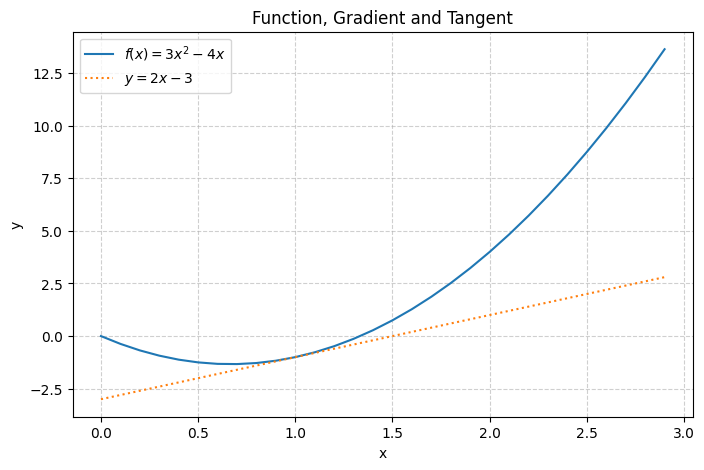

In [4]:
import matplotlib.pyplot as plt

# 1. Plot function at points x = 0 to x = 3 with step = 0.1
x = np.arange(0, 3, 0.1) 

# 2. Define our function, include the tangent at x = 1
y1 = 3 * x**2 - 4 * x  # f(x) = 3x^2 - 4x
y2 = 2 * x - 3         # y = 2x - 3

# 3. Define the graph
plt.figure(figsize=(8, 5))

# 4. Plot our function on the graph
plt.plot(x, y1, label='$f(x) = 3x^2 - 4x$', linestyle='-')

# 5. Plot the tangent line on our graph
plt.plot(x, y2, label='$y = 2x - 3$', linestyle=':')

# 6. Give the graph a title and label both axes
#    Include dotted grid lines for clarity
plt.title('Function, Gradient and Tangent')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 7. Display the graph
plt.show()

## 2.4.3. Partial Derivatives and Gradients

For functions with multiple variables, we have the concept of a partial derivative. The partial derivative of a mutivariate function with respect to one of its variables is defined similarly to the single-variable case. We simply hold all other variables constant and take the limit for the variable referenced in the partial derivative.

When we consider vectors with variables as elements, we can then define a function on the vector as taking all elements \(variable\) as inputs and returning a single scalar output. Then, the derivative of this function is a vector of the same size as the input vector, where each element of the resulting vector is the partial derivative of the original function with respect to each element in the original vector. 

The derivatives of such functions have some interesting properties when combined with matrix-vector multiplication, transpose and norm. In particular, the derivatives themselves can be expressed as a combination of matrix additions, transpose and matrix-vector multiplication.

## 2.4.4. Chain Rule

Chain rule is a rule in differentiation where given a function $y = h(x)$, we introduce an intermediate variable $u$ where $u = f(x)$ and $y = g(u)$. Then, we have the below result known as chain rule.

$$
\begin{align}
\frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx}
\end{align}
$$

Extending this to partial derivatives is straightforward. For each intermediate variable $u_{i}$, we hold the other variables constant and apply the chain rule as per the single-variable case. Then, we sum these partial derivatives to get the final result. This is the chain rule for multivariate case.

Viewing multivariate functions as functions operating on vector-valued variables and returning a scalar value, we find something interesting - the derivative of $y$ with respect to input vector $\mathbf{x}$ can be expressed in the form $\mathbf{A} \nabla_{\mathbf{u}} y$ where $\mathbf{u}$ is the intermediate vector variable and $A$ is a matrix representing the derivative of $\mathbf{u}$ with respect to $\mathbf{x}$.

This means the derivative of vector-valued functions can be computed as a series of matrix-vector and matrix-matrix multiplications, an important result used in _automatic differentiation_ \(autograd\) forming the backbone of machine learning.

## 2.4.5. Discussion

This should be enough calculus to get us started with machine learning :-\)

## 2.4.6. Exercises

Skipped as they are mostly written textbook exercises with few related to hands-on programming.